In [22]:
%matplotlib inline

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import json
from pathlib import Path
import re
from scipy.stats import spearmanr, kendalltau

import sys
sys.path.insert(1, "../")

from dependencies.data_generator import load_dataset, load_dataset_on_inference
from dependencies.train_config import TrainConfig

from train_surrogate import SurrogateTrainer
from inference_surrogate import InferSurrogate

from tqdm.auto import tqdm
np.random.seed(42)

In [3]:
params = json.loads(
    Path(
        "/home/alexander/RAS/m1p/predicator-function-for-neural-networks/code/configs/surrogate_hp_CIFAR100.json"
    ).read_text()
)
config = TrainConfig(**params)

In [4]:
load_dataset(config)

Loading 2925 random ACC models: 100%|██████████| 2925/2925 [00:00<00:00, 1530672.39it/s]


Loading 2925 random DIV models: 100%|██████████| 2925/2925 [00:00<00:00, 1915132.56it/s]


In [5]:
inference = InferSurrogate(config)
inference.initialize_models()

Initializing surrogate models...
Surrogate models loaded successfully.


In [6]:
model_diversity = inference.model_diversity.to("cpu")
model_accuracy = inference.model_accuracy.to("cpu")

In [7]:
config.dataset_path

'/home/alexander/RAS/m1p/predicator-function-for-neural-networks/code/datasets/CIFAR100_united/architectures'

In [8]:
config.models_dict_path = []
config.dataset_path = Path(config.dataset_path)
for file_path in config.dataset_path.rglob("*.json"):
    config.models_dict_path.append(file_path)

In [9]:
initial_archs = []
for arch_json_path in tqdm(config.models_dict_path, desc="Loading pretrained archs"):
    arch = json.loads(arch_json_path.read_text(encoding="utf-8"))
    for key in ("test_predictions", "test_accuracy", "valid_predictions", "valid_accuracy"):
        arch.pop(key, None)
    arch["id"] = int(re.search(r"model_(\d+)", str(arch_json_path)).group(1))
    initial_archs.append(arch)

Loading pretrained archs:   0%|          | 0/2925 [00:00<?, ?it/s]

In [10]:
archs, accs_np, embs_np = inference._get_embeddings(initial_archs)

/home/alexander/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 20 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Extracting accuracy predictions...


100%|██████████| 1/1 [00:22<00:00, 22.88s/it]


Extracting diversity embeddings...


100%|██████████| 1/1 [00:35<00:00, 35.33s/it]


In [11]:
trainer = SurrogateTrainer(config)
trainer.get_diversity_matrix()

Preparing predictions:   0%|          | 0/2925 [00:00<?, ?it/s]

100%|██████████| 2925/2925 [00:00<00:00, 3047.87it/s]


In [12]:
diversity_matrix = trainer.config.diversity_matrix

In [13]:
print(f"Shape of diversity_matrix: {diversity_matrix.shape}")
print(f"Shape of embs_np: {embs_np.shape}")

Shape of diversity_matrix: (2925, 2925)
Shape of embs_np: (2925, 16)


In [14]:
# Получим количество архитектур
n_archs = len(archs)

# Разделим индексы на train и test в пропорции 0.8 / 0.2
indices = np.arange(n_archs)
np.random.shuffle(indices)

train_size = int(0.8 * n_archs)
train_indices = indices[:train_size]
test_indices = indices[train_size:]

In [15]:
print(f"Всего архитектур: {n_archs}")
print(f"Размер тренировочного набора: {len(train_indices)}")
print(f"Размер тестового набора: {len(test_indices)}")

Всего архитектур: 2925
Размер тренировочного набора: 2340
Размер тестового набора: 585


In [16]:
# Функция для выбора случайных пар без повторов и без i == j
def get_random_pairs(indices1, indices2, n_pairs):
    """
    Создает список уникальных пар индексов (i, j), где i != j
    """
    pairs = set()
    while len(pairs) < n_pairs:
        i = np.random.choice(indices1)
        j = np.random.choice(indices2)
        if i != j:
            # Используем sorted, чтобы (i,j) и (j,i) считались одной парой
            pairs.add(tuple(sorted((i, j))))
    return list(pairs)

In [17]:
# Выберем пары для анализа
n_pairs = 1000  # количество пар для каждой категории

# Пары трейн-трейн
train_train_pairs = get_random_pairs(train_indices, train_indices, n_pairs)

# Пары трейн-тест
train_test_pairs = get_random_pairs(train_indices, test_indices, n_pairs)

# Пары тест-тест
test_test_pairs = get_random_pairs(test_indices, test_indices, n_pairs)

In [18]:
def compute_metrics(pairs):
    """
    Вычисляет похожесть, расстояние, а также корреляции Спирмена и Кендалла
    """
    similarities = []
    distances = []
    for i, j in pairs:
        similarities.append(diversity_matrix[i, j])
        distances.append(np.linalg.norm(embs_np[i] - embs_np[j]))
    
    similarities = np.array(similarities)
    distances = np.array(distances)
    
    # Вычисляем корреляции
    spearman_corr, spearman_p = spearmanr(distances, similarities)
    kendall_corr, kendall_p = kendalltau(distances, similarities)
    
    return similarities, distances, spearman_corr, spearman_p, kendall_corr, kendall_p


In [19]:
similarities_tt, distances_tt, sp_tt, sp_p_tt, kd_tt, kd_p_tt = compute_metrics(
    train_train_pairs
)
similarities_ttest, distances_ttest, sp_ttest, sp_p_ttest, kd_ttest, kd_p_ttest = (
    compute_metrics(train_test_pairs)
)
(
    similarities_testtest,
    distances_testtest,
    sp_testtest,
    sp_p_testtest,
    kd_testtest,
    kd_p_testtest,
) = compute_metrics(test_test_pairs)

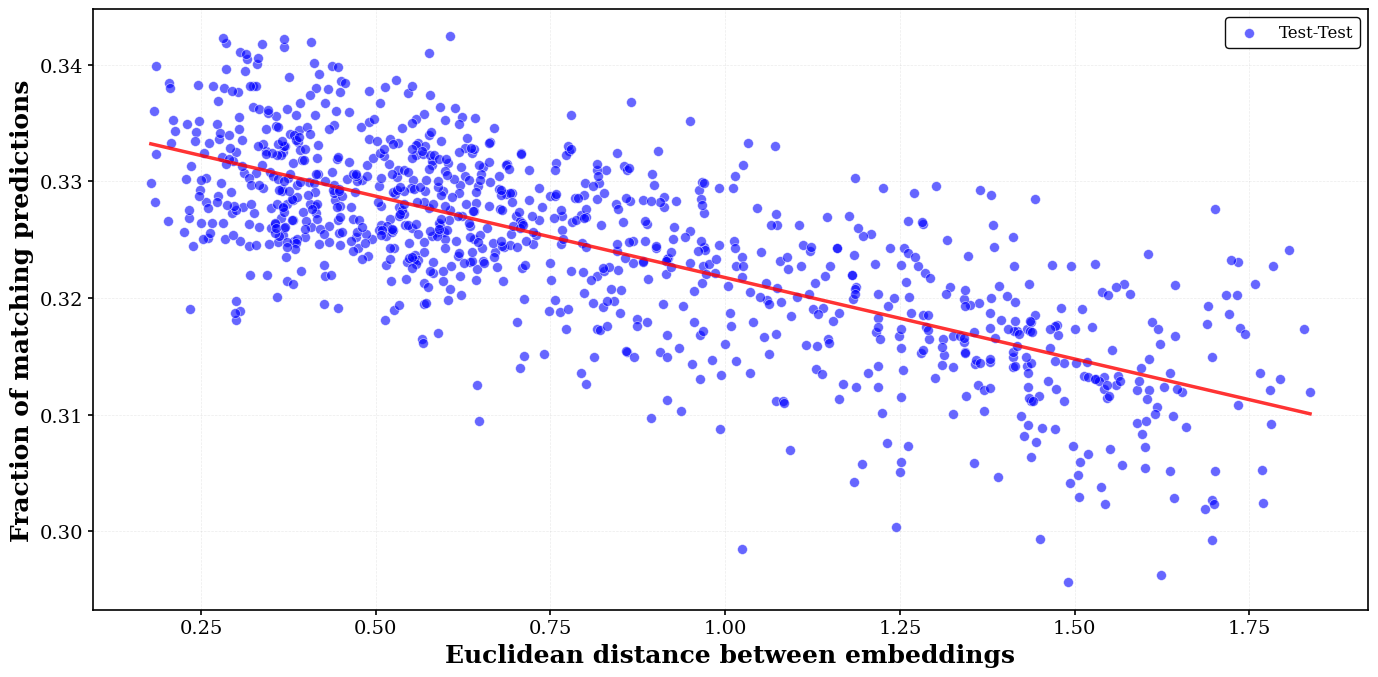

In [24]:
# Publication-ready plot styling
plt.figure(figsize=(14, 7))

# Set serif font for academic publication style
plt.rcParams.update(
    {
        "font.family": "serif",
        "font.serif": ["Times New Roman", "DejaVu Serif"],
        "font.size": 14,
        "axes.labelsize": 18,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        "legend.fontsize": 12,
        "axes.linewidth": 1.2,
        "xtick.major.width": 1.2,
        "ytick.major.width": 1.2,
    }
)

# Scatter plots with enhanced visibility
# scatter1 = plt.scatter(distances_tt, similarities_tt,
#                       alpha=0.6, label='Train-Train',
#                       color='#1f77b4', s=50, edgecolors='white', linewidth=0.5)
# scatter2 = plt.scatter(distances_ttest, similarities_ttest,
#                       alpha=0.6, label='Train-Test',
#                       color='#ff7f0e', s=50, edgecolors='white', linewidth=0.5)
scatter3 = plt.scatter(
    distances_testtest,
    similarities_testtest,
    alpha=0.6,
    label="Test-Test",
    color="blue",
    s=50,
    edgecolors="white",
    linewidth=0.5,
)

# Добавление линии аппроксимации для Test-Test
# Линейная аппроксимация с использованием полинома первой степени
if len(distances_testtest) > 1:
    coeffs = np.polyfit(distances_testtest, similarities_testtest, 1)
    poly_func = np.poly1d(coeffs)

    # Создание значений X для гладкой линии
    x_line = np.linspace(min(distances_testtest), max(distances_testtest), 100)
    y_line = poly_func(x_line)

    # Рисование линии аппроксимации
    plt.plot(
        x_line,
        y_line,
        color="red",
        linewidth=2.5,
        #  label=f'Fit: y = {coeffs[0]:.3f}x + {coeffs[1]:.3f}',
        linestyle="-",
        alpha=0.8,
    )

# Axis labels (no title for publication)
plt.xlabel("Euclidean distance between embeddings", fontsize=18, fontweight="bold")
plt.ylabel("Fraction of matching predictions", fontsize=18, fontweight="bold")

# Professional legend (без тени)
plt.legend(
    loc="upper right",
    fontsize=12,
    framealpha=0.95,
    edgecolor="black",
    fancybox=True,
    shadow=False,
)  # Убраны тени

# Subtle grid
plt.grid(True, alpha=0.15, linestyle="--", linewidth=0.5, color="gray")

# Clean background
plt.gca().set_facecolor("white")
plt.tight_layout()

# Optional: Save as high-resolution PDF for LaTeX integration
plt.savefig("embedding_correlation.pdf", dpi=300, bbox_inches="tight", format="pdf")

plt.show();

In [21]:
# Выведем статистику по каждой категории
print("\n" + "=" * 50)
print("СТАТИСТИКА ПО КАТЕГОРИЯМ ПАР")
print("=" * 50)


def print_stats(name, sim, dist, sp, sp_p, kd, kd_p):
    print(f"\n{name} пары ({len(sim)} пар):")
    print(f"   - Средняя похожесть: {np.mean(sim):.4f} ± {np.std(sim):.4f}")
    print(f"   - Среднее расстояние: {np.mean(dist):.4f} ± {np.std(dist):.4f}")
    print(f"   - Корреляция Спирмена: {sp:.4f} (p-value: {sp_p:.2e})")
    print(f"   - Корреляция Кендалла: {kd:.4f} (p-value: {kd_p:.2e})")


print_stats(
    "ТРЕЙН-ТРЕЙН", similarities_tt, distances_tt, sp_tt, sp_p_tt, kd_tt, kd_p_tt
)
print_stats(
    "ТРЕЙН-ТЕСТ",
    similarities_ttest,
    distances_ttest,
    sp_ttest,
    sp_p_ttest,
    kd_ttest,
    kd_p_ttest,
)
print_stats(
    "ТЕСТ-ТЕСТ",
    similarities_testtest,
    distances_testtest,
    sp_testtest,
    sp_p_testtest,
    kd_testtest,
    kd_p_testtest,
)


СТАТИСТИКА ПО КАТЕГОРИЯМ ПАР

ТРЕЙН-ТРЕЙН пары (1000 пар):
   - Средняя похожесть: 0.3244 ± 0.0086
   - Среднее расстояние: 0.8010 ± 0.4012
   - Корреляция Спирмена: -0.7151 (p-value: 2.34e-157)
   - Корреляция Кендалла: -0.5194 (p-value: 1.95e-133)

ТРЕЙН-ТЕСТ пары (1000 пар):
   - Средняя похожесть: 0.3246 ± 0.0088
   - Среднее расстояние: 0.7987 ± 0.4126
   - Корреляция Спирмена: -0.7354 (p-value: 7.81e-171)
   - Корреляция Кендалла: -0.5352 (p-value: 1.42e-141)

ТЕСТ-ТЕСТ пары (1000 пар):
   - Средняя похожесть: 0.3243 ± 0.0081
   - Среднее расстояние: 0.8184 ± 0.4271
   - Корреляция Спирмена: -0.7144 (p-value: 6.60e-157)
   - Корреляция Кендалла: -0.5150 (p-value: 3.06e-131)
